# setup

In [ ]:

! pip install sentinelhub[AWS]  # extra dependencies for interacting with Amazon Web Services
! pip install s2cloudless
! pip install shapely

import json
from shapely.geometry import shape # para sacar el bbox usando las coords de cada reservoir

import datetime as dt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sentinelhub import CRS, BBox, DataCollection, MimeType, SentinelHubRequest, SHConfig, generate_evalscript, Geometry
from sentinelhub.api.catalog import get_available_timestamps
from sentinelhub.geo_utils import bbox_to_dimensions

from s2cloudless import S2PixelCloudDetector, download_bands_and_valid_data_mask

from google.colab import userdata
CLIENT_ID = userdata.get('client_id')
CLIENT_SECRET = userdata.get('client_secret')
INSTANCE_ID = userdata.get('instance_id')

config = SHConfig()

assert CLIENT_ID and CLIENT_SECRET and INSTANCE_ID #CLIENT_ID and CLIENT_SECRET and INSTANCE_ID están en secrets en el notebook
config.sh_client_id = CLIENT_ID
config.sh_client_secret = CLIENT_SECRET


# clase para almacenar la info (geometrías) particular de cada reservoir
class ReservoirShape:
  def __init__ (self, geometry, bbox, size, dataMask):
    self.geometry = geometry
    self.bbox = bbox
    self.size = size
    self.dataMask = dataMask

# Útiles para datos satelitales

In [ ]:
def apiReqRez(data_collection, fecha, evalscript, reservoirShape):
  """
  Envía una solicitud a la API de Sentinel Hub y recupera datos geoespaciales.
  Args:
    data_collection (DataCollection): La colección de datos a usar (por ejemplo, DataCollection.SENTINEL2_L2A).
    fecha (str): Fecha en formato "YYYY-MM-DD" para la que tiene que existir una imagen para la misión especificada en 'data_collection'.
    evalscript (str): El Evalscript utilizado para hacer la solicitud a la API. Ver https://docs.sentinel-hub.com/api/latest/evalscript/.
  Returns:
    numpy.ndarray: La respuesta de la API. Si ha sido exitosa, un numpy.ndarray con la lectura satelital.
  """

  assert isinstance(reservoirShape, ReservoirShape), "reservoirShape param must be an instance of ReservoirShape."
  request = SentinelHubRequest(
      evalscript=evalscript,
      input_data=[
          SentinelHubRequest.input_data(
              data_collection=data_collection,
              time_interval=fecha
              )
          ],
      responses=[
          SentinelHubRequest.output_response("default", MimeType.TIFF),
      ],

      bbox=reservoirShape.bbox,
      geometry=reservoirShape.geometry,
      size=reservoirShape.size,

      config=config,
  )

  response = request.get_data() # API call

  return response[0] # el [0] porque devuelve lista de responses

DM_EVALSCRPT = '''
    //VERSION=3

    function setup() {
        return {
            input: [{
                bands: ["dataMask"],
                units: ["DN"]
            }],
            output: {
              bands: 1
            }
        }
    }

    function updateOutputMetadata(scenes, inputMetadata, outputMetadata) {
        outputMetadata.userData = {
            "norm_factor":  inputMetadata.normalizationFactor
        }
    }

    function evaluatePixel(sample) {
        return [sample.dataMask];
    }

  '''

NUBES_EVALSCRPT = '''
    //VERSION=3

    function setup() {
        return {
            input: [{
                bands: ["B01", "B02", "B04", "B05", "B08", "B8A", "B09", "B10", "B11", "B12"],
                units: ["REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE"]
            }],
            output: {
              bands: 10,
              sampleType: "FLOAT32"
            }
        }
    }

    function updateOutputMetadata(scenes, inputMetadata, outputMetadata) {
        outputMetadata.userData = {
            "norm_factor":  inputMetadata.normalizationFactor
        }
    }

    function evaluatePixel(sample) {
        return [sample.B01, sample.B02, sample.B04, sample.B05, sample.B08, sample.B8A, sample.B09, sample.B10, sample.B11, sample.B12];
    }

  '''

AGUA_EVALSCRPT = '''
  //VERSION 3
    function setup() {
        return {
            input: [{
              bands: ["B03", "B08"],
              units: ["REFLECTANCE", "REFLECTANCE"]
            }],
            output: {
              bands: 1,
              sampleType: "FLOAT32"
            }

        }
    }

    //para preservar el factor de normalización
    function updateOutputMetadata(scenes, inputMetadata, outputMetadata) {
        outputMetadata.userData = {
            "norm_factor":  inputMetadata.normalizationFactor
        }
    }


    function evaluatePixel(samples) {
        return[index(samples.B03, samples.B08)];
    }


  '''

ALLBANDS_EVALSCRPT = '''
    //VERSION=3

    function setup() {
        return {
            input: [{
                bands: ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12"],
                units: ["REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE", "REFLECTANCE"]
            }],
            output: {
              bands: 12,
              sampleType: "FLOAT32"
            }
        }
    }

    function updateOutputMetadata(scenes, inputMetadata, outputMetadata) {
        outputMetadata.userData = {
            "norm_factor":  inputMetadata.normalizationFactor
        }
    }

    function evaluatePixel(sample) {
        return [sample.B01, sample.B02, sample.B03, sample.B04, sample.B05, sample.B06, sample.B07, sample.B08, sample.B8A, sample.B09, sample.B11, sample.B12];
    }

  '''

B9x11_EVALSCRPT = '''
  //VERSION=3
  function evaluatePixel(samples) {
    let val = samples.B09*samples.B11
    return [val];
  }

  function setup() {
    return {
      input: [{
        bands: [
          "B09",
          "B11",
        ]
      }],
      output: {
        bands: 1,
        sampleType: "FLOAT32"
      }
    }
  }
'''


In [ ]:
# para conseguir las available dates hay que usar una configuration instance (q se crean en el sh dashboard) y una de sus capas, para la que qiueras comprobar las fechas
from sentinelhub.api.ogc import OgcImageService, OgcRequest
from sentinelhub.constants import ServiceType

def obtencionFechas(intervalo, reservoirShape):
  """
  Obtiene una lista de fechas para un intervalo de tiempo en las que se ha hecho una lectura
  satelital con las características de la capa 'layer4fechas' creada en el dashboard de Sentinel Hub.
  Args:
    intervalo (tuple): Una tupla que especifica el intervalo de tiempo (fecha_inicio, fecha_fin)
              en el formato ('YYYY-MM-DD', 'YYYY-MM-DD').
  Returns:
    list: Una lista ordenada de fechas únicas (cadenas en formato 'YYYY-MM-DD')
        que representan fechas válidas dentro del intervalo especificado.
  """

  ois_config = config.copy() # creamos una config nueva
  ois_config.instance_id = INSTANCE_ID # hace falta una conf. instance en la que este la layer q usamos para preguntar por las fechas
  ois_config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
  ois_config.sh_base_url = "https://sh.dataspace.copernicus.eu"
  ois = OgcImageService(config=ois_config)

  request = OgcRequest(
      layer = 'layer4fechas', # el nombre en sh dashboard de la layer con el evalscrpt = allbands_evalscript
      bbox = reservoirShape.bbox,
      data_collection = DataCollection.SENTINEL2_L2A,
      time = intervalo,
      service_type = ServiceType.WMS,
      config = ois_config,
      size_x = int(np.ceil(reservoirShape.size[0])),
      size_y = int(np.ceil(reservoirShape.size[1])),
      )
  response = ois.get_dates(request)
  fechas = [dt_obj.strftime('%Y-%m-%d') for dt_obj in response] # lista de fechas validas en formato 'yyyy-mm-dd'
  fechas = list(set(fechas)) # quitamos duplicados
  fechas.sort() # ordenamos

  return fechas

En la celda siguiente en la funcion `curvasEnFechas(fechas)` se devuelve 'rezDf', en el que en el que para cada fecha en '`fechas`' se almacena la media de cada banda de la imagen tomada ese día, para todas las fechas en las que el nº de px con agua y sin nubes están por encima de `minPrctgPx`

In [ ]:
# Calculo de nº minimio de px validos (sin agua o nubes) en una img para tenerla en cuenta
aquaThres = 0.5 # se asumirán con agua los px cuyo indice en la mascara de agua > aquaThres
todasBandasNames = ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12']

# minPrctgPx es el % min de px del pantano que tienen que ser validos para no descartar la imagen
# rezEvalscript es el que se usará para hacer la apicall cuyo resultado será devuelto tras aplicar las mascaras de aguaynubes
# noms_bandas es un array con el nombre, en orden, de las bandas que se devuelven segun rezEvalscript, para dar nombre a las columnas del df resultante
def curvasEnFechas(fechas, minPrctgPx = .01, rezEvalscript=ALLBANDS_EVALSCRPT, noms_bandas=todasBandasNames, reservoirShape=None):
  """
  Calcula las curvas de valores promedio de las lecturas de las bandas especificadas para un conjunto de fechas,
  considerando únicamente los píxeles válidos (sin nubes y con agua) dentro de la geometría descrita en `reservoirShape`.
  Parámetros:
  -----------
  fechas : list
    Lista de fechas para las cuales se desean procesar las lecturas de la misión Sentinel-2. En formato "YYYY-MM-DD".
  minPrctgPx : float, opcional
    Porcentaje mínimo de píxeles válidos (válido = no está cubierto por nubes y y su índice NDWI > `aquaThres`) requeridos
    para considerar una lectura individual como válida. Por defecto es 0.01 (1%).
  rezEvalscript : str, opcional
    Evalscript utilizado para obtener los datos de las bandas cuyas curvas se quieran calcular.
    Por defecto es `ALLBANDS_EVALSCRPT`.
  noms_bandas : list, opcional
    Lista con los nombres de las bandas a procesar. Por defecto es `todasBandasNames`.
  reservoirShape : ReservoirShape, opcional
    Geometría que del embalse a analizar, en un objeto de la clase 'ReservoirShape'.
  Devuelve:
  --------
  rezDf : pandas.DataFrame
    DataFrame con las fechas como índice y las bandas como columnas.
    Para cada fecha en `fechas` se almacena la media de cada banda de la imagen tomada ese día,
    para todas las fechas en las que el nº de px con agua y sin nubes están por encima de `minPrctgPx`
    Cada columna representa la curva de valores promedio, para cada fecha, de las lecturas de una banda.
    Si una fecha no tiene suficientes píxeles válidos, se asigna NaN.
  """

  # peticion de un dia cualquiera para obtener la mascara con la forma del pantano
  dataMask = apiReqRez(DataCollection.SENTINEL2_L2A, fechas[0], DM_EVALSCRPT, reservoirShape=reservoirShape)

  print('curvasEnFechas SIN TERMINAR: HAY QUE HACER QUE COJA LA FECHA PARA LA DATAMASK PARA LA QUE MÁS PX = 1 HAYA')
  return


  minValidPx = int(np.count_nonzero(dataMask)*minPrctgPx) # nº min de px validos del pantano

  # Df para guardar los resultados indexado para que en las fechas sin imagen valida haya NaN
  rezDf = pd.DataFrame(index=fechas, columns=noms_bandas)

  # Procesado
  for fecha in fechas:
    # Comprobacion de que hay suficientes px sin nubes
    nubesData = apiReqRez(DataCollection.SENTINEL2_L1C, fecha, NUBES_EVALSCRPT, reservoirShape)
    cloud_detector = S2PixelCloudDetector(threshold=0.4, average_over=4, dilation_size=2, all_bands=False) #OJO: Si en NUBES_EVALSCRPT no estan todas las bandas hay q cambiar param 'all_bands'
    cloudMask = cloud_detector.get_cloud_masks(nubesData[np.newaxis, ...])[0]
    cloudMasknt = ~cloudMask & dataMask # 1o: se invierte cloudmask para q zonas sin nubes = 1; 2o se aplica dataMask para poner px fuera del pantano = 0
    nPxSinNubes = int(np.count_nonzero(cloudMasknt))
    if nPxSinNubes < minValidPx:
      continue # marcar fecha invalida

    else:
      # Comprobacion de que hay suficientes px con agua
      aguaData = apiReqRez(DataCollection.SENTINEL2_L2A, fecha, AGUA_EVALSCRPT, reservoirShape)
      aquaMask = np.where(aguaData > aquaThres, 1, 0)
      nPxSinNubesOAgua = int(np.count_nonzero(cloudMasknt & aquaMask))
      if nPxSinNubesOAgua < minValidPx:
        continue # marcar fecha invalida
      else:
        # Se calcula y guarda el promedio de cada banda
        allBandsData = apiReqRez(DataCollection.SENTINEL2_L2A, fecha, rezEvalscript, reservoirShape)
        bandas = allBandsData.transpose(2, 0, 1) # la API req devuelve (x,y,12) siendo x,y las dims de la img

        for i, banda in enumerate(bandas):
          cloudNaquaMask = aquaMask & cloudMasknt
          pxValidos = banda[cloudNaquaMask == 1] # array de los px validos (sin nubes y con agua)
          rezDf.loc[fecha, noms_bandas[i]] = np.mean(pxValidos)# guardamos la media de los valores px validos

  return rezDf

In [ ]:
def imgEnFecha(fecha, minPrctgPx = .01, rezEvalscript=ALLBANDS_EVALSCRPT, reservoirShape=None):

  dataMask = reservoirShape.dataMask

  minValidPx = int(np.count_nonzero(dataMask)*minPrctgPx) # nº min de px validos del pantano
  if minValidPx == 0:
    minValidPx = 1 # cuerpos de agua que abarquen pocos px de las imagenes deberan abarcar 1 px minimo

  # Comprobacion de que hay suficientes px sin nubes
  nubesData = apiReqRez(DataCollection.SENTINEL2_L1C, fecha, NUBES_EVALSCRPT, reservoirShape)
  cloud_detector = S2PixelCloudDetector(threshold=0.4, average_over=4, dilation_size=2, all_bands=False) #OJO: Si en NUBES_EVALSCRPT no estan todas las bandas hay q cambiar param 'all_bands'
  cloudMask = cloud_detector.get_cloud_masks(nubesData[np.newaxis, ...])[0]
  cloudMasknt = ~cloudMask & dataMask # 1o: se invierte cloudmask para q zonas sin nubes = 1; 2o se aplica dataMask para poner px fuera del pantano = 0
  nPxSinNubes = int(np.count_nonzero(cloudMasknt))
  if nPxSinNubes < minValidPx:
    return None # fecha sin imagen válida

  else:
    # Comprobacion de que hay suficientes px con agua
    aguaData = apiReqRez(DataCollection.SENTINEL2_L2A, fecha, AGUA_EVALSCRPT, reservoirShape)
    aquaMask = np.where(aguaData > aquaThres, 1, 0)
    nPxSinNubesOAgua = int(np.count_nonzero(cloudMasknt & aquaMask))
    if nPxSinNubesOAgua < minValidPx:
      return None # fecha sin imagen válida
    else:
      # Se calcula y guarda el promedio de los pixeles vaidos en la imagen
      apiCallResult = apiReqRez(DataCollection.SENTINEL2_L2A, fecha, rezEvalscript, reservoirShape)
      cloudNaquaMask = aquaMask & cloudMasknt
      pxValidos = apiCallResult[cloudNaquaMask == 1] # array de los px validos (sin nubes y con agua)

      return np.mean(pxValidos) # guardamos la media de los valores px validos


# Preprocesado Dataset4

##Se cargan los datos crudos

Aclaración: se habla de 'cianolectura' para referirse a mediciones de concentraciones de cianobacterias en el dataset.

In [ ]:
# preparación
import os
os.chdir('./tmp')  # para guardar los datos

import pickle

# Se cargan las formas de los embalses de eeuu

def load_pickle_df(filename):
    """
    Loads a dataframe from a file saved using pickle.

    Args:
        filename (str): The name of the file to load the dataframe from.

    Returns:
        dict or None: The loaded dataframe of class instances, or None if an error occurs.
    """
    try:
        with open(filename, 'rb') as f:
            loaded_df = pickle.load(f)
        print(f"dataframe loaded from '{filename}'")
        return loaded_df
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found.")
        return None
    except Exception as e:
        print(f"Error loading dataframe from '{filename}': {e}")
        return None

Mounted at /content/drive


In [ ]:
# saco datos de los pantanos de eeuu 
file_path = './raw_datasets/Dataset4.csv'
try:
  datosRaw = pd.read_csv(file_path)
except FileNotFoundError:
  print(f"Error: File not found at {file_path}")
except Exception as e:
  print(f"An error occurred: {e}")

df = datosRaw[['lat(degrees)',	'lon(degrees)',	'date(yyyymmdd)',	'abun(cells/L)',	'distance_to_water(m)']].copy()

df = df.rename(columns={'date(yyyymmdd)': 'date', 'lat(degrees)': 'lat', 'lon(degrees)': 'lon'}) # cambia nombres columnas


def transformar_coordenadas(df):
    """
    Transforma las columnas 'lat' y 'lon' de un DataFrame según tal que las latitudes que no estén
    en [20,75] y las longitudes que no estén en  [-125,-75] (esto es porque son reservoirs de eeuu
    y eeuu esta dentro de esos limites) deben ser divididas por 10 ^(su nºdigitos -2), a no ser que
    sea una longitud menor que -125 y empiece en ‘1’, en cuyo caso habría de ser dividida por
    10^(su nºdigitos -3).

    Args:
        df (pd.DataFrame): DataFrame con columnas 'lat' y 'lon'.

    Returns:
        pd.DataFrame: DataFrame con las columnas 'lat' y 'lon' transformadas.
    """

    def transformar_latitud(lat):
        if not 20 <= lat <= 75:
            num_digitos = len(str(int(abs(lat))))
            return lat / (10**(num_digitos - 2))
        return lat

    def transformar_longitud(lon):
        if not -125 <= lon <= -75:
            lon_str = str(lon)
            num_digitos = len(str(int(abs(lon))))
            if lon < -125 and lon_str.startswith('-1'):
                return lon / (10**(num_digitos - 3))
            else:
                return lon / (10**(num_digitos - 2))
        return lon

    df.loc[:, 'lat'] = df['lat'].apply(transformar_latitud)
    df.loc[:, 'lon'] = df['lon'].apply(transformar_longitud)

    return df

# every date not within 2017 to 2024 dropped because the no sentinel L2A outside of that timeframe
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')
df = df[(df['date'].dt.year >= 2017) & (df['date'].dt.year <= 2024)]

# Convert 'date' to datetime objects and then format to 'YYYY-MM-DD'
df.loc[:, 'date'] = df['date'].dt.strftime('%Y-%m-%d')
clean_df = transformar_coordenadas(df)
eeuu_data2 = clean_df.reset_index(drop=True).copy() # index reset so .iloc works fine in this df

## Se consiguen las geometrías de los pantanos

Solicitud a la api de OSM de las geometrias del embalse (reservoir) más cercano a las coordenadas de cada cianolectura:

In [ ]:
import requests
import json

def get_lake_reservoir_geometry(latitude, longitude, m_to_water):
    """
    Requests the geometry of lakes or reservoirs from OpenStreetMap (OSM)
    given coordinates 'm_to_water' meters close to the waterbody.

    Args:
        latitude (float): The latitude of a point near the waterbody.
        longitude (float): The longitude of a point near the waterbody.

    Returns:
        dict or None: A dictionary containing the GeoJSON geometry of the
                     lake or reservoir if found, otherwise None.
                     The dictionary will have keys: 'type' (Multipolygon|Polygon),
                     and 'coordinates' (GeoJSON).
                     Returns None if no lake or reservoir is found nearby.
    """



    search_radius = m_to_water+50 # just to be sure
    overpass_url = "http://overpass-api.de/api/interpreter"
    overpass_query = f"""
    [out:json];
    (
      relation(around:{search_radius},{latitude},{longitude})["water"~"lake|reservoir"];
    );
    (._;>;);
    out geom;
    """
    try:
      response = requests.get(overpass_url, params={'data': overpass_query})
      response.raise_for_status()  # Raise an exception for bad status codes
      data = response.json()

      for element in data['elements']:
        if 'tags' in element and 'water' in element['tags'] and element['tags']['water'] in ['lake', 'reservoir']:
          multipoligono = []

          for member in element['members']:
            if member['type'] == 'way' and member['role'] == 'outer' and 'geometry' in member:
              # se guarda el poligono como lista de lista de coordenadas: [[[coord['lon'], coord['lat']]] porque así lo espera la funcion shape
              multipoligono.append([[[coord['lon'], coord['lat']] for coord in member['geometry']]])

          if len(multipoligono) >=1:
            # la api devuelve algunos poligonos con menos de 4 coordenadas, y estos hacen que shape() falle, invalidando todo el resto de poligonos
            # se eliminan estos poligonos demasiado simples, de todas maneras no son descriptivos del embalse
            fixed_multipoly = []
            for poli in multipoligono:
              if len(poli[0]) > 4:
                fixed_multipoly.append(poli)

            multipoligono = fixed_multipoly

            ret_shape = None
            if len(multipoligono) == 1:
              ret_shape = shape({
                "type": 'polygon',
                "coordinates": multipoligono[0]
              })
            else:
              ret_shape = shape({
                  "type": 'multipolygon',
                  "coordinates": multipoligono
              })

            # el poligono puede estar mal construido (e.g. intersecciones consigo mismo) para la peticion hay que arreglarlo
            if not ret_shape.is_valid:
              ret_shape = ret_shape.buffer(0) # solución

              # si el resultado es un multipoligono puede ser que se haya dividido el original en varios más pequeños para arreglar la geometría
              if ret_shape.geom_type == 'MultiPolygon':
                # se asume que el más complejo de los poligonos resultantes de arreglar el poligono original será el más descriptivo del lago
                most_complex = None
                max_complexity = 0

                for polygon in ret_shape.geoms:  # Iterate through polygons
                  complexity = len(polygon.exterior.coords)
                  if complexity > max_complexity:
                    max_complexity = complexity
                    most_complex = polygon

                ret_shape = most_complex

            return ret_shape

      return None

    except requests.exceptions.RequestException as e:
        print(f"Error during Overpass API request: {e}")
        return None
    except json.JSONDecodeError:
        print("Error decoding JSON response from Overpass API.")
        return None
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return None

latitude = 39.08031907
longitude = -86.43086667

poli = get_lake_reservoir_geometry(latitude, longitude,50)
print(poli)
print(type(poli))


POLYGON ((-86.3886867 39.0749682, -86.37101229326991 39.080092521684044, -86.33272277018133 39.09119376182358, -86.3279087 39.0925895, -86.3294975 39.0917686, -86.3305939 39.0908476, -86.3302821 39.0876799, -86.3288676 39.0843389, -86.3278371 39.0835404, -86.3278236 39.0835299, -86.3259121 39.0845009, -86.3254598 39.0850086, -86.3251189 39.0849422, -86.3250554 39.0842779, -86.3241942 39.0841285, -86.324095 39.0835911, -86.3256942 39.0835185, -86.3269592 39.0826694, -86.3259012 39.0815748, -86.3254076 39.0805995, -86.3243742 39.0804277, -86.3223942 39.0789405, -86.3208393 39.0780843, -86.3201462 39.0781575, -86.3193501 39.0772297, -86.3199857 39.0769618, -86.3187772 39.0753724, -86.3199209 39.0732685, -86.3192084 39.0721812, -86.3194467 39.0716326, -86.3180927 39.0704531, -86.3184982 39.0696685, -86.3198887 39.0698234, -86.3215883 39.0724413, -86.32191 39.0724072, -86.3220409 39.0696868, -86.3203028 39.0682058, -86.3198794 39.0686499, -86.319176 39.0691253, -86.318186 39.0690949, -86.31

In [ ]:
import traceback

eeuu_data_n_shapes = pd.DataFrame()
n_saved_rows = 0

# esta celda se tuvo que ejecutar varias veces para iterar a través de todo el dataset, y por
# ello se almacenó el progreso de ejecuciones anteriores para no comenzar de nuevo desde la primera cianolectura en el dataset
import os
directorio_actual = os.path.basename(os.getcwd())
assert directorio_actual == 'tmp', "error: cambiar al directorio 'tmp'"

# si ha habido ejecuciones anteriores en las que se ha guardado el estado
if os.path.exists('dataset4_preprocessing.pkl'):
  # Se carga el DataFrame
  with open('dataset4_preprocessing.pkl', 'rb') as file:
      eeuu_data_n_shapes = pickle.load(file)

  ult_fila = eeuu_data_n_shapes.tail(1).iloc[:, :-1].copy() # ult_fila es la ultima fila creada en eeuu_data_n_shapes
  # index_comienzo es el indice de la ultima fila en eeuu_data2 de la que se consiguió obtener un ReservoirShape en ejecuciones de esta celda anteriores
  index_comienzo = eeuu_data2[eeuu_data2[ult_fila.columns].eq(ult_fila.values.squeeze()).all(axis=1)].index[0]
else:
  index_comienzo = -1 # caso en que no ha habido pruebas anteriores

# el bucle comienza desde la cianolectura 'index_comienzo' y asi no se vuelven a buscar ReservoirShapes ya encontrados
for index, cianolectura in eeuu_data2.iloc[index_comienzo+1:].iterrows():
  print('\nprocesando cianolectura ',index,'/',len(eeuu_data2),' - lat: ',cianolectura['lat'],'lon: ', cianolectura['lon'])

  reservoir_shape = get_lake_reservoir_geometry(cianolectura['lat'],cianolectura['lon'], cianolectura['distance_to_water(m)'])
  if reservoir_shape is None:
    print('No se ha encontrado geometry para este cuerpo de agua')
    continue
  display(reservoir_shape)
  try:

    bbox = BBox(bbox=list(reservoir_shape.bounds), crs=CRS.WGS84) # geometry.bounds es la bbox como tupla
    geometry = Geometry(geometry=reservoir_shape, crs=CRS.WGS84)
    size = bbox_to_dimensions(bbox, resolution=60) #60m de resolution pq es la resolucion de las bandas q vamos a usar

    dataMask = None # se guarda la dataMask como None por ahora, porque es necesario utilizar reservoir_shapes para encontrarlas

    new_row = cianolectura.to_dict()
    new_row['shape'] = ReservoirShape(geometry, bbox, size, dataMask)

    # Append the new row to eeuu_data_n_shapes
    eeuu_data_n_shapes = pd.concat([eeuu_data_n_shapes, pd.DataFrame([new_row])], ignore_index=True)

    # Cada 100 ReservoirShapes encontrados se guarda el progreso en un archivo
    if (n_saved_rows + 1) % 100 == 0:  # Check if the current iteration is a multiple of 100
      with open('dataset4_preprocessing.pkl', 'wb') as file:
        pickle.dump(eeuu_data_n_shapes, file)
      print(f"DataFrame saved to 'dataset4_preprocessing.pkl' with row {index + 1}")

    n_saved_rows+=1
  except Exception as e:
    print(f"An error occurred: {e}")
    print("Traceback:")
    # This function prints the standard traceback information to sys.stderr
    traceback.print_exc()


# Save the DataFrame one last time after the loop completes
with open('dataset4_preprocessing.pkl', 'wb') as file:
  pickle.dump(eeuu_data_n_shapes, file)
print("Final DataFrame saved to 'dataset4_preprocessing.pkl'")


## Se consiguen las máscaras de datos

Funciones para trabajar con fechas y obtencion de toda fecha con imagenes de todo pantano

In [ ]:
from datetime import datetime, timedelta

def find_closest_previous_date(dates_list, target_date_str):
  """
  Finds the closest previous date in a list of datetime objects.

  Args:
    dates_list: A list of datetime objects.
    target_date_str: The target date string in the format 'YYYY-MM-DD'.

  Returns:
    The closest previous date in the list in string format, or None if no such date is found.
  """

  target_date = datetime.strptime(target_date_str, '%Y-%m-%d')

  # Find closest previous date
  closest_previous_date = None
  min_diff = float('inf')
  for date in dates_list:
    diff = target_date - date
    if diff >= timedelta(0) and diff.days < min_diff:  # Check if previous and closer
      min_diff = diff.days
      closest_previous_date = date

  # Return as string if found
  return closest_previous_date.strftime('%Y-%m-%d') if closest_previous_date else None


def days_diff(date1_str, date2_str):
  """Calculates the difference in days between two dates.

  Args:
    date1_str: The first date string in 'yyyy-mm-dd' format.
    date2_str: The second date string in 'yyyy-mm-dd' format.

  Returns:
    The difference in days between the two dates, which can be 0.
  """
  date1 = datetime.strptime(date1_str, '%Y-%m-%d')
  date2 = datetime.strptime(date2_str, '%Y-%m-%d')
  diff = abs((date2 - date1).days)  # Use abs() to ensure a positive difference
  return diff


In [ ]:
print('len before dropping: ',len(eeuu_data_n_shapes))
# se interpretan como outliers las ReservoirShape con size = (0,1), se droppean:
eeuu_data_n_shapes = eeuu_data_n_shapes[eeuu_data_n_shapes['shape'].apply(lambda obj: obj.size != (0, 1))]
print('len after dropping: ',len(eeuu_data_n_shapes))

# se consiguen los dataMask de cada pantano
for index, cianolectura in eeuu_data_n_shapes.iterrows():
    print('processing ',index,'/',len(eeuu_data_n_shapes))
    diez_dias_prior = (cianolectura['date'] - timedelta(days=11)).strftime("%Y-%m-%d")
    close_dates = obtencionFechas((diez_dias_prior, cianolectura['date']), cianolectura['shape'])
    close_dates = [datetime.strptime(fecha, '%Y-%m-%d') for fecha in close_dates]

    img_date = find_closest_previous_date(close_dates, cianolectura['date'].strftime("%Y-%m-%d"))

    dataMask = apiReqRez(DataCollection.SENTINEL2_L2A, img_date, DM_EVALSCRPT, cianolectura['shape'])
    eeuu_data_n_shapes.loc[index,'shape'].dataMask = dataMask
    display(dataMask)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
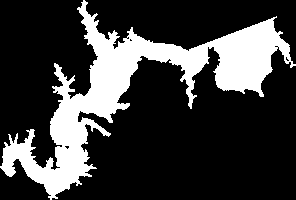

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
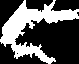

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
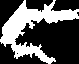

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0, 255, 255],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255, 255],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255, 255],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255, 255],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255, 255],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255, 255],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255, 255],
       [  0,   0,   0,   0,   0,   0,   0,   0, 255, 255,   0],
       [  0,   0,   0,   0,   0,   0,   0, 255, 255, 255,   0],
       [  0,   0,   0,   0,   0,   0,   0, 255, 255, 255,   0],
       [  0,   0,   0,   0,   0,   0, 255, 255, 255,   0,   0],
       [  0,   0,   0,   0,   0,   0, 255, 255, 255,   0,   0],
       [  0,   0,   0,   0,   0,   0, 255, 255, 255,   0,   0],
       [  0,   0,   0,   0,   0,   0, 255, 255, 255,   0,   0],
       [  0,   0,   0,   0,   0,   0, 255, 255, 255, 255,   0],
       [  0,   0,   0,   0,   0, 255, 255, 255, 255, 255,   0],
       [  0,   0,   0,   0, 255, 255, 255, 255, 255, 255,   0],
       [  0,   0,   0,   0, 255, 255, 255, 255, 255, 255,   0],
       [  0,   0,   0, 255, 255, 255, 255, 255, 255, 255,   0],
       [  0,   0,   0, 255, 255, 255, 255, 255, 255,   0,   0],
       [  0,   0, 255, 255, 255, 255, 255, 255,   0,   0,   0],
       [  0,   0, 255, 255, 255, 255, 255,   0,   0,   0,   0],
       [  0, 255, 255, 255, 255, 255, 255,   0,   0,   0,   0],
       [255, 255, 255, 255, 255, 255,   0,   0,   0,   0,   0],
       [255, 255, 255, 255, 255,   0,   0,   0,   0,   0,   0],
       [255, 255, 255, 255,   0,   0,   0,   0,   0,   0,   0],
       [255, 255, 255,   0,   0,   0,   0,   0,   0,   0,   0]],
      dtype=uint8)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
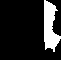

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,   0, 255],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8)
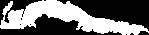

array([[  0,   0,   0, ...,   0,   0, 255],
       [  0,   0,   0, ...,   0, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8)
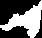

array([[  0,   0,   0, ...,   0,   0, 255],
       [  0,   0,   0, ...,   0, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8)
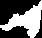

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
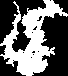

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0, 255, 255, 255,   0,
          0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 255, 255, 255, 255,   0,
          0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 255, 255, 255, 255, 255, 255,
          0, 255, 255,   0],
       [  0,   0,   0,   0,   0,   0,   0, 255, 255, 255, 255, 255, 255,
        255, 255, 255, 255],
       [  0,   0,   0,   0,   0,   0,   0, 255, 255, 255, 255, 255, 255,
        255, 255, 255, 255],
       [  0,   0,   0,   0,   0,   0,   0, 255, 255, 255, 255, 255, 255,
        255, 255, 255, 255],
       [  0,   0,   0,   0,   0,   0,   0, 255, 255, 255, 255, 255, 255,
        255, 255, 255, 255],
       [  0,   0,   0,   0,   0, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255, 255, 255],
       [  0,   0,   0,   0, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255, 255, 255],
       [  0,   0, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255, 255,   0],
       [  0,   0, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,   0,
        255, 255,   0,   0],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,   0,   0,
          0,   0,   0,   0],
       [255, 255, 255, 255, 255, 255, 255, 255, 255,   0,   0,   0,   0,
          0,   0,   0,   0],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0, 255, 255, 255, 255, 255, 255, 255, 255,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,   0,   0, 255, 255, 255, 255, 255,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0, 255, 255, 255,   0,   0,   0,   0,
          0,   0,   0,   0]], dtype=uint8)

In [ ]:
# muestra del resultado
for i,cl in eeuu_data_n_shapes.iloc[500:510].iterrows():
  display(cl['shape'].dataMask)

In [ ]:
with open('dataset4_preprocessing.pkl', 'wb') as file:
  pickle.dump(eeuu_data_n_shapes, file)
print("DataFrame saved to 'dataset4_preprocessing.pkl'")


DataFrame saved to 'dataset2_preprocessing.pkl'


## Se crean datos finales

In [ ]:
eeuu_data_n_shapes = load_pickle_df('./dataset4_preprocessing.pkl')

def assign_group_dataset4(density):
  # para el Dataset4 las lecturas de cianobacterias están en células/L. dado que los niveles de
  # alerta de la oms son en celulas/mL se divide
  density_mL = density / 1000
  if density_mL <= 200:
    return 0
  elif density_mL <= 2000:
    return 1
  elif density_mL <= 20000:
    return 2
  elif density_mL <= 100000:
    return 3
  elif density_mL > 100000:
    return 4
  else:
    return -1

# columnas 'promedio', 'peso' y 'etiqueta' para el entrenamiento y validación de los modelos, y
# 'og_index', que indica el índice de la cianolectura en 'eeuu_data_n_shapes' con la que se ha
# creado el dato final
final_data2 = pd.DataFrame(columns=['promedio','peso','label','og_index'])
n_saved_rows = 0

# esta celda se tuvo que ejecutar varias veces para iterar a través de todo el dataset, y por
# ello se almacenó el progreso de ejecuciones anteriores para no comenzar de nuevo desde la primera cianolectura en el dataset

# si ha habido ejecuciones anteriores en las que se ha guardado el estado
if os.path.exists('final_data_Dataset4.pkl'):
  # Load the DataFrame using pickle.load()
  with open('final_data_Dataset4.pkl', 'rb') as file:
      final_data2 = pickle.load(file)
  index_comienzo = final_data2['og_index'].iloc[-1]
else:
  index_comienzo = -1

for index, cianolectura in eeuu_data_n_shapes.iloc[index_comienzo+1:].iterrows():
  print('\nprocesando cianolectura ',index,'/',len(eeuu_data_n_shapes))
  dato = {} # dict que será el nuevo dato en final_data2

  # primero se obtienen la lista de fechas con imágenes cercanas a la cianolectura
  doce_dias_prior = (cianolectura['date'] - timedelta(days=12)).strftime("%Y-%m-%d")
  close_dates = obtencionFechas((doce_dias_prior, cianolectura['date'].strftime("%Y-%m-%d")), cianolectura['shape'])
  close_dates = [datetime.strptime(fecha, '%Y-%m-%d') for fecha in close_dates]

  img_date = find_closest_previous_date(close_dates, cianolectura['date'].strftime("%Y-%m-%d"))
  if img_date is None:
    print('Error: no se ha encontrado fecha con imagen en los 12 dias antes de cianolectura. (no debería ocurrir)')
    continue # no hay fecha con imagenes antes de una lectura (no debería ocurrir)

  promedio_img = imgEnFecha(img_date, rezEvalscript=B9x11_EVALSCRPT, reservoirShape=cianolectura['shape'])
  if promedio_img is None:
    print('Imagen descartada por filtrado')
    continue # demasiadas nubes o muy poca agua
  else:
    dato['og_index'] = index
    dato['peso'] = days_diff(img_date, cianolectura['date'].strftime("%Y-%m-%d"))
    dato['promedio'] = promedio_img
    dato['label'] = assign_group_dataset4(cianolectura['abun(cells/L)'])
    final_data2.loc[len(final_data2)] = dato
    print('Imagen guardada:',dato)

    # Cada 100 ReservoirShapes encontrados se guarda el progreso en un archivo
    if (n_saved_rows + 1) % 100 == 0:  # Check if the current iteration is a multiple of 100
      with open('final_data_Dataset4.pkl', 'wb') as file:
        pickle.dump(final_data2, file)
      print(f"DataFrame saved to 'final_data_Dataset4.pkl' with row {index + 1}")

    n_saved_rows+=1

import os
directorio_actual = os.path.basename(os.getcwd())
assert directorio_actual == 'tmp', "error: cambiar al directorio 'tmp'"

print(f"Current Working Directory: {os.getcwd()}")
with open('final_data_Dataset4.pkl', 'wb') as file:
  pickle.dump(final_data2, file)

Streaming output truncated to the last 5000 lines.
Imagen descartada por filtrado

procesando cianolectura  1 / 1666
Imagen guardada: {'og_index': 1, 'peso': 0, 'promedio': np.float32(0.00014280742), 'label': 2}

procesando cianolectura  2 / 1666
Imagen descartada por filtrado

procesando cianolectura  3 / 1666
Imagen descartada por filtrado

procesando cianolectura  4 / 1666
Imagen descartada por filtrado

procesando cianolectura  5 / 1666
Imagen descartada por filtrado

procesando cianolectura  6 / 1666
Imagen descartada por filtrado

procesando cianolectura  7 / 1666
Imagen descartada por filtrado

procesando cianolectura  8 / 1666
Imagen descartada por filtrado

procesando cianolectura  9 / 1666
Imagen descartada por filtrado

procesando cianolectura  10 / 1666
Imagen guardada: {'og_index': 10, 'peso': 2, 'promedio': np.float32(0.00039604778), 'label': 0}

procesando cianolectura  11 / 1666
Imagen descartada por filtrado

procesando cianolectura  12 / 1666
Imagen descartada por fil

In [ ]:
print('len final data: ',len(final_data2))
final_data2 = final_data2.dropna(subset=['promedio'])
final_data2 = final_data2.reset_index(drop=True)  # drop=True avoids old index becoming a column

print('len after dropna: ',len(final_data2))

len final data:  458
len after dropna:  458


In [ ]:
import os
directorio_actual = os.path.basename(os.getcwd())
assert directorio_actual == 'tmp', "error: cambiar al directorio 'tmp'"

print(f"Current Working Directory: {os.getcwd()}")
with open('final_data_Dataset4.pkl', 'wb') as file:
  pickle.dump(final_data2, file)


Current Working Directory: /content/drive/My Drive/colaboI3A/tmp


In [ ]:
eeuu_data_n_shapes = load_pickle_df('./dataset4_preprocessing.pkl')


# modelo usa datos

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import os
directorio_actual = os.path.basename(os.getcwd())
assert directorio_actual == 'tmp', "error: cambiar al directorio 'tmp'"

data = load_pickle_df('./final_data_Dataset4.pkl')
print('numero de cianolecturas de cada nivel de alerta: ')
display(data['label'].value_counts())


dataframe loaded from '/content/drive/My Drive/colaboI3A/tmp/final_data_Dataset4.pkl'
numero de cianolecturas de cada nivel de alerta: 


,count
label,
0,296
1,68
4,64
2,18
3,12


## Separacion en atributos y etiquetas, entrenamiento y test

In [ ]:
# Separate features (X) and target (y)
X = data[['promedio', 'peso']]
y = data['label']

# El dataset esta claramente desbalanceado, se hace undersampling de la clase 0: se escogen 68
# indices aleatorios de la clase 0 para que haya tantos como de la siguiente clase mas frecuente
selected_indices = np.random.choice(np.where(y==0)[0], size=68, replace=False)
# se crea una mascara que pone a true todos los datos que no son de la clase 0 U los que estan en selected_indices
mask = np.logical_or(y != 0, np.isin(np.arange(len(y)), selected_indices))

# Undersampling
X = X[mask]
y = y[mask]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)  # Adjust test_size and random_state as needed
print('x train: ',X_train.shape)
print('y train: ',y_train.shape)
print('x test: ',X_test.shape)
print('y test: ',y_test.shape)
print()
print('Total support: ')
display(y.value_counts())
print()
print('Train support: ')
display(y_train.value_counts())
print()
print('Test support: ')
display(y_test.value_counts())


x train:  (184, 2)
y train:  (184,)
x test:  (46, 2)
y test:  (46,)

Total support: 


,count
label,
0,68
1,68
4,64
2,18
3,12



Train support: 


,count
label,
1,55
0,54
4,51
2,14
3,10



Test support: 


,count
label,
0,14
1,13
4,13
2,4
3,2


### Atributos y etiquetas para clasificación binaria

In [ ]:
# El dataset esta claramente desbalanceado, se hace undersampling de la clase 0: se escogen 68
# indices aleatorios de la clase 0 para que haya tantos como de la siguiente clase mas frecuente
label_0_subset_df = data[data['label'] == 0].sample(n=68, random_state=42) # cjto de 68 filas con la label 0

# Filter original DataFrame to keep only sampled rows and rows with 'label' != 0
data_bin = data[(data.index.isin(label_0_subset_df.index)) | (data['label'] != 0)].copy()

# se cambian las etiquetas para convertirlo en un problema de clasificación binaria
data_bin['label'] = np.where(data_bin['label']<2, 0, 1)

# Separate features (X) and target (y)
X_bin = data_bin[['promedio', 'peso']]
y_bin = data_bin['label']

# Split data into training and testing sets
X_bin_train, X_bin_test, y_bin_train, y_bin_test = train_test_split(X_bin, y_bin, test_size=0.2, random_state=42)  # Adjust test_size and random_state as needed
print('x_bin train: ',X_bin_train.shape)
print('y_bin train: ',y_bin_train.shape)
print('x_bin test: ',X_bin_test.shape)
print('y_bin test: ',y_bin_test.shape)
print()
print('Total support: ')
display(y_bin.value_counts())
print()
print('Train support: ')
display(y_bin_train.value_counts())
print()
print('Test support: ')
display(y_bin_test.value_counts())

x_bin train:  (184, 2)
y_bin train:  (184,)
x_bin test:  (46, 2)
y_bin test:  (46,)

Total support: 


,count
label,
0,136
1,94



Train support: 


,count
label,
0,106
1,78



Test support: 


,count
label,
0,30
1,16


Algo desbalanceado aún, pero mejor que en el caso multiclase

## Regresión Logística

In [ ]:
# Create a logistic regression model
logReg = LogisticRegression(class_weight='balanced', max_iter=1000)  # Adjust max_iter if needed

# Train the logReg
logReg.fit(X_train, y_train)

# Make predictions on the test set
y_pred = logReg.predict(X_test)

# Overall accuracy, classification report and conf. matrix
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred,zero_division=0))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.1956521739130435
              precision    recall  f1-score   support

           0       0.45      0.56      0.50        16
           1       0.00      0.00      0.00        13
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        16

    accuracy                           0.20        46
   macro avg       0.11      0.14      0.12        46
weighted avg       0.16      0.20      0.17        46

[[9 0 5 2]
 [3 0 7 3]
 [1 0 0 0]
 [7 0 9 0]]


Pruebo a usar el solver `'liblinear'`, pensado para datasets pequeños. Mejora un poco con regularización lasso pero aun así mal

In [ ]:
from sklearn.multiclass import OneVsRestClassifier
# Create a logistic regression model
logReg2 = OneVsRestClassifier(LogisticRegression(class_weight='balanced', solver='liblinear', penalty = 'l1', max_iter=1000))

# Train the logReg2
logReg2.fit(X_train, y_train)

# Make predictions on the test set
y_pred = logReg2.predict(X_test)

# Overall accuracy, classification report and conf. matrix
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred,zero_division=0))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.2608695652173913
              precision    recall  f1-score   support

           0       0.45      0.56      0.50        16
           1       0.60      0.23      0.33        13
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        16

    accuracy                           0.26        46
   macro avg       0.26      0.20      0.21        46
weighted avg       0.33      0.26      0.27        46

[[9 2 5 0]
 [3 3 7 0]
 [1 0 0 0]
 [7 0 9 0]]


Plot de los datos muestran que las clases son difícilmente linealmente separables

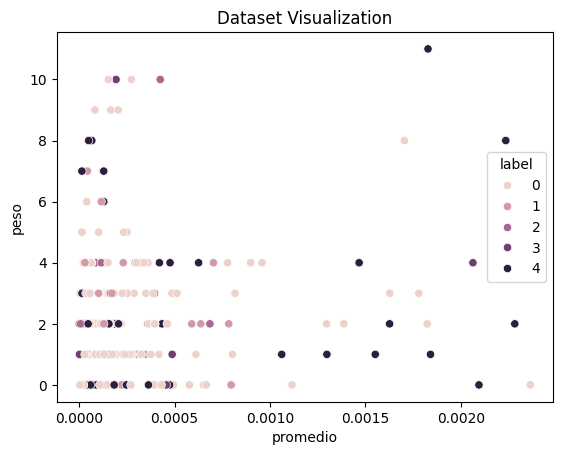

In [ ]:
import seaborn as sns
df = data[data['promedio']<0.01].copy() #pq hay outliers >.01
sns.scatterplot(x='promedio', y='peso', hue='label', data=df)
plt.title('Dataset Visualization')
plt.show()

## Random forests

In [ ]:
from sklearn.ensemble import RandomForestClassifier

randForest = RandomForestClassifier(n_estimators=200, random_state=34, class_weight='balanced_subsample', n_jobs=-1)
randForest.fit(X_train, y_train)
y_pred = randForest.predict(X_test)

# Overall accuracy, classification report and conf. matrix
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred, zero_division=0))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.41304347826086957
              precision    recall  f1-score   support

           0       0.53      0.56      0.55        16
           1       0.27      0.23      0.25        13
           2       0.00      0.00      0.00         4
           3       0.00      0.00      0.00         2
           4       0.50      0.64      0.56        11

    accuracy                           0.41        46
   macro avg       0.26      0.29      0.27        46
weighted avg       0.38      0.41      0.39        46

[[9 4 1 0 2]
 [5 3 3 0 2]
 [1 1 0 0 2]
 [1 0 0 0 1]
 [1 3 0 0 7]]


### Prueba clasificacion binaria
no alertar: clases 0,1

alertar: clases 2,3,4

In [ ]:
randForest_bin = RandomForestClassifier(n_estimators=200, random_state=34, class_weight='balanced_subsample', n_jobs=-1)
randForest_bin.fit(X_bin_train, y_bin_train)
y_bin_pred = randForest_bin.predict(X_bin_test)

# Overall accuracy, classification report and conf. matrix
print(f"Accuracy: {accuracy_score(y_bin_test, y_bin_pred)}")
print(classification_report(y_bin_test, y_bin_pred, zero_division=0))
print(confusion_matrix(y_bin_test, y_bin_pred))

Accuracy: 0.8478260869565217
              precision    recall  f1-score   support

           0       0.87      0.90      0.89        30
           1       0.80      0.75      0.77        16

    accuracy                           0.85        46
   macro avg       0.84      0.82      0.83        46
weighted avg       0.85      0.85      0.85        46

[[27  3]
 [ 4 12]]


## GradientBoost

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# incrementar n_estimators no tiene apenas efecto
gradBoost = GradientBoostingClassifier(random_state=34, n_estimators=200)
gradBoost.fit(X_train,y_train)
y_pred = gradBoost.predict(X_test)

# Overall accuracy, classification report and conf. matrix
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred,zero_division=0))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.32608695652173914
              precision    recall  f1-score   support

           0       0.41      0.44      0.42        16
           1       0.33      0.38      0.36        13
           2       0.00      0.00      0.00         4
           3       0.00      0.00      0.00         2
           4       0.30      0.27      0.29        11

    accuracy                           0.33        46
   macro avg       0.21      0.22      0.21        46
weighted avg       0.31      0.33      0.32        46

[[7 5 1 0 3]
 [6 5 1 0 1]
 [1 0 0 0 3]
 [0 2 0 0 0]
 [3 3 1 1 3]]


### Clasificación binaria

In [ ]:
gradBoost = GradientBoostingClassifier(random_state=34, n_estimators=100)
gradBoost.fit(X_bin_train,y_bin_train)
y_bin_pred = gradBoost.predict(X_bin_test)


# Overall accuracy, classification report and conf. matrix
print(f"Accuracy: {accuracy_score(y_bin_test, y_bin_pred)}")
print(classification_report(y_bin_test, y_bin_pred, zero_division=0))
print(confusion_matrix(y_bin_test, y_bin_pred))

Accuracy: 0.7608695652173914
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        30
           1       0.67      0.62      0.65        16

    accuracy                           0.76        46
   macro avg       0.74      0.73      0.73        46
weighted avg       0.76      0.76      0.76        46

[[25  5]
 [ 6 10]]


## AdaBoost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

adaBoost =AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2, random_state=34),
                             n_estimators=200, random_state=34)
adaBoost.fit(X_train, y_train)
y_pred = adaBoost.predict(X_test)

# Overall accuracy, classification report and conf. matrix
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred,zero_division=0))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.2608695652173913
              precision    recall  f1-score   support

           0       0.27      0.25      0.26        16
           1       0.23      0.38      0.29        13
           2       0.00      0.00      0.00         4
           3       0.00      0.00      0.00         2
           4       0.33      0.27      0.30        11

    accuracy                           0.26        46
   macro avg       0.17      0.18      0.17        46
weighted avg       0.24      0.26      0.24        46

[[ 4 10  0  0  2]
 [ 6  5  0  0  2]
 [ 1  2  0  0  1]
 [ 0  1  0  0  1]
 [ 4  4  0  0  3]]


### Clasificación binaria

In [ ]:
adaBoost =AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2, random_state=34),
                             n_estimators=200, random_state=34)
adaBoost.fit(X_bin_train, y_bin_train)
y_bin_pred = adaBoost.predict(X_bin_test)

# Overall accuracy, classification report and conf. matrix
print(f"Accuracy: {accuracy_score(y_bin_test, y_bin_pred)}")
print(classification_report(y_bin_test, y_bin_pred, zero_division=0))
print(confusion_matrix(y_bin_test, y_bin_pred))

Accuracy: 0.782608695652174
              precision    recall  f1-score   support

           0       0.86      0.80      0.83        30
           1       0.67      0.75      0.71        16

    accuracy                           0.78        46
   macro avg       0.76      0.78      0.77        46
weighted avg       0.79      0.78      0.79        46

[[24  6]
 [ 4 12]]


## XGBoost

In [ ]:
import xgboost as xgb

xgBoost = xgb.XGBClassifier(objective='binary:logistic', seed=34)
xgBoost.fit(X_train, y_train)
y_pred = xgBoost.predict(X_test)

# Overall accuracy, classification report and conf. matrix
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred,zero_division=0))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.3695652173913043
              precision    recall  f1-score   support

           0       0.38      0.21      0.27        14
           1       0.37      0.54      0.44        13
           2       0.00      0.00      0.00         4
           3       0.00      0.00      0.00         2
           4       0.50      0.54      0.52        13

    accuracy                           0.37        46
   macro avg       0.25      0.26      0.25        46
weighted avg       0.36      0.37      0.35        46

[[3 7 1 0 3]
 [4 7 0 1 1]
 [1 1 0 0 2]
 [0 1 0 0 1]
 [0 3 1 2 7]]


In [ ]:
xgBoost = xgb.XGBClassifier(objective='binary:logistic', seed=34)
xgBoost.fit(X_bin_train, y_bin_train)
y_bin_pred = xgBoost.predict(X_bin_test)

# Overall accuracy, classification report and conf. matrix
print(f"Accuracy: {accuracy_score(y_bin_test, y_bin_pred)}")
print(classification_report(y_bin_test, y_bin_pred, zero_division=0))
print(confusion_matrix(y_bin_test, y_bin_pred))

Accuracy: 0.8478260869565217
              precision    recall  f1-score   support

           0       0.90      0.87      0.88        30
           1       0.76      0.81      0.79        16

    accuracy                           0.85        46
   macro avg       0.83      0.84      0.83        46
weighted avg       0.85      0.85      0.85        46

[[26  4]
 [ 3 13]]
